In [1]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [1]. [Tạo file kaggle.json từ thông tin tài khoản của tôi]

import os, json

kaggle_dir = os.path.join(os.path.expanduser("~"), ".kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

kaggle_json_path = os.path.join(kaggle_dir, "kaggle.json")

kaggle_info = {
    "username": "username",     # 👉 sửa lại: username Kaggle của em
    "key": "kaggle_api_key"           # 👉 dán key Kaggle của em vào đây
}

with open(kaggle_json_path, "w") as f:
    json.dump(kaggle_info, f)

# set permission (đặc biệt quan trọng trên Linux/Colab)
try:
    os.chmod(kaggle_json_path, 0o600)
except:
    pass

print("Đã tạo:", kaggle_json_path)
print("Nội dung kaggle.json đã được ghi (không in ra để bảo mật).")


Đã tạo: C:\Users\Admin\.kaggle\kaggle.json
Nội dung kaggle.json đã được ghi (không in ra để bảo mật).


# Case Study 8 – Multiclass classification với Softmax (15 loại quần áo)

**Mục tiêu:**
- Xây dựng bài toán phân loại **15 loại quần áo**:
  - 10 lớp từ **Fashion-MNIST**.
  - 5 lớp từ **dataset thời trang Kaggle** (Fashion Product Images Small).
- Mô tả dữ liệu:
  - Kích thước ảnh (28×28, grayscale).
  - Phân bố số lượng mẫu theo từng lớp.
- Xây dựng mô hình CNN **≥ 7 layer (không tính Dropout)** bằng TensorFlow/Keras.
- Sử dụng:
  - Hàm kích hoạt **Softmax** ở đầu ra cho phân loại đa lớp.
  - Hàm mất mát **Sparse Categorical Cross-Entropy**.
- Trực quan hóa:
  - Phân bố dữ liệu.
  - Quá trình huấn luyện (loss/val_loss, acc/val_acc).
  - Confusion matrix trên tập test.

**Dataset:**
- Fashion-MNIST (10 lớp quần áo, ảnh 28×28 grayscale).  
- Fashion Product Images (Small) – trích 5 loại: Skirt, Shorts, Jacket, Sweater, Hat.



In [2]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [2]. [Import thư viện & đặt seed]

import os
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## 1. Cấu hình Kaggle API

Để tải dataset từ Kaggle bằng code, cần:

1. Vào Kaggle → Profile → Account → API → **Create New Token**.
2. Tải file `kaggle.json`.
3. Copy `kaggle.json` vào thư mục:
   - Trên Windows: `C:\Users\<UserName>\.kaggle\kaggle.json`
   - Trên Linux/Colab: `/root/.kaggle/kaggle.json` hoặc `~/.kaggle/kaggle.json`

Sau đó chạy các cell bên dưới để tải dataset **Fashion Product Images (Small)**.


In [4]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [4]. [Cài kaggle & kiểm tra kaggle.json]



home_dir = os.path.expanduser("~")
kaggle_dir = os.path.join(home_dir, ".kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

print("Thư mục .kaggle:", kaggle_dir)
print("Các file hiện có:", os.listdir(kaggle_dir))

if "kaggle.json" not in os.listdir(kaggle_dir):
    print("\n⚠️ Chưa tìm thấy kaggle.json. Hãy copy file kaggle.json vào thư mục trên rồi chạy lại cell.")
else:
    print("\n✅ Đã tìm thấy kaggle.json – sẵn sàng tải dataset từ Kaggle.")


Thư mục .kaggle: C:\Users\Admin\.kaggle
Các file hiện có: ['kaggle.json']

✅ Đã tìm thấy kaggle.json – sẵn sàng tải dataset từ Kaggle.


In [ ]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [5]. [Tải & giải nén Fashion Product Images (Small) từ Kaggle]

download_dir = "./kaggle_data"
os.makedirs(download_dir, exist_ok=True)

# Dataset: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
!kaggle datasets download -d paramaggarwal/fashion-product-images-small -p {download_dir} --force

print("Các file tải về:", os.listdir(download_dir))

# Giải nén file zip
zip_files = [f for f in os.listdir(download_dir) if f.endswith(".zip")]
if not zip_files:
    raise FileNotFoundError("Không tìm thấy file .zip trong thư mục tải về.")

zip_path = os.path.join(download_dir, zip_files[0])
extract_dir = "./fashion_product_small"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(extract_dir)

print("Đã giải nén vào:", extract_dir)
print("Nội dung thư mục:", os.listdir(extract_dir))



  0%|          | 0.00/565M [00:00<?, ?B/s]
  0%|          | 1.00M/565M [00:02<22:18, 442kB/s]
  0%|          | 2.00M/565M [00:03<16:48, 586kB/s]
  1%|          | 3.00M/565M [00:04<13:31, 726kB/s]
  1%|          | 4.00M/565M [00:05<11:17, 869kB/s]
  1%|          | 5.00M/565M [00:06<08:28, 1.15MB/s]
  1%|1         | 6.00M/565M [00:06<06:48, 1.43MB/s]
  1%|1         | 7.00M/565M [00:07<06:31, 1.49MB/s]
  1%|1         | 8.00M/565M [00:08<07:30, 1.30MB/s]
  2%|1         | 9.00M/565M [00:09<08:36, 1.13MB/s]
  2%|1         | 10.0M/565M [00:10<10:01, 968kB/s] 
  2%|1         | 11.0M/565M [00:12<10:56, 885kB/s]
  2%|2         | 12.0M/565M [00:12<08:26, 1.15MB/s]
  2%|2         | 13.0M/565M [00:12<06:16, 1.54MB/s]
  2%|2         | 14.0M/565M [00:12<04:54, 1.97MB/s]
  3%|2         | 15.0M/565M [00:12<03:54, 2.46MB/s]
  3%|2         | 16.0M/565M [00:13<03:29, 2.75MB/s]
  3%|3         | 17.0M/565M [00:13<03:40, 2.61MB/s]
  3%|3         | 18.0M/565M [00:14<03:57, 2.41MB/s]
  3%|3         | 19.0M/56

Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT

Các file tải về: ['fashion-product-images-small.zip']


In [ ]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [7]. [Xem các articleType phổ biến trong dataset]

# Giả sử df_styles đã được đọc ở cell trước:
# styles_path = os.path.join(extract_dir, "styles.csv")
# df_styles = pd.read_csv(styles_path, on_bad_lines='skip')

print("Số loại articleType khác nhau:", df_styles["articleType"].nunique())
print("\nTop 20 articleType phổ biến nhất:")
print(df_styles["articleType"].value_counts().head(20))


# Case Study 8 – Multiclass Classification với Softmax (15 loại quần áo)

**Mục tiêu chính:**

- Kết hợp:
  - 10 lớp từ **Fashion-MNIST** (Zalando) – ảnh 28×28, grayscale.
  - 5 lớp quần áo thêm từ dataset **Fashion Product Images (Small)** (Kaggle).
- Chuẩn hóa tất cả về cùng định dạng:
  - Ảnh `28×28×1`, giá trị pixel chuẩn hóa `[0,1]`.
  - Nhãn là số nguyên từ 0 đến 14.
- Xây dựng mô hình **CNN ≥ 7 layer (không tính Dropout)**, đầu ra **Softmax**, loss **Sparse Categorical Cross-Entropy**.
- Trực quan hóa:
  - Phân bố dữ liệu theo lớp.
  - Quá trình huấn luyện (loss/val_loss, acc/val_acc).
  - Confusion matrix trên tập test.

**Dataset sử dụng:**

- Fashion-MNIST (10 lớp): tải qua `tf.keras.datasets.fashion_mnist`.
- Fashion Product Images (Small) – Kaggle (đã tải thủ công và giải nén):
  - Link tham khảo: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
  - Ta trích 5 loại quần áo **không trùng** với 10 lớp Fashion-MNIST:
    - `Kurtas`, `Jeans`, `Briefs`, `Socks`, `Belts`.


In [17]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [2]. [Import thư viện & đặt seed, đường dẫn]

import os
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # 👈 THÊM Dropout Ở ĐÂY
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras import regularizers  # 👈 để dùng l2

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

extract_dir = "./fashion_product_small"
styles_path = os.path.join(extract_dir, "styles.csv")
images_dir = os.path.join(extract_dir, "images")

print("TensorFlow version:", tf.__version__)
print("Thư mục dataset Kaggle:", extract_dir)


TensorFlow version: 2.20.0
Thư mục dataset Kaggle: ./fashion_product_small


## 1. Đọc styles.csv & khảo sát cột `articleType`

File `styles.csv` của dataset Kaggle chứa metadata cho từng sản phẩm:

- `id`: mã ảnh (tương ứng file `images/<id>.jpg`).
- `articleType`: loại sản phẩm (Tshirts, Kurtas, Jeans, ...).
- Một số cột khác: gender, baseColour, season, ...

Bước này:

1. Đọc `styles.csv` (bỏ qua những dòng lỗi format nếu có).
2. Kiểm tra kích thước, tên cột.
3. In thống kê `value_counts()` của `articleType` để biết những loại phổ biến.


In [8]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [4]. [Đọc styles.csv & xem thống kê articleType]

df_styles = pd.read_csv(styles_path, on_bad_lines='skip')

print("Kích thước styles.csv:", df_styles.shape)
print("Các cột:", df_styles.columns.tolist())

print("\nTop 20 articleType phổ biến:")
print(df_styles["articleType"].value_counts().head(20))


Kích thước styles.csv: (44424, 10)
Các cột: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']

Top 20 articleType phổ biến:
articleType
Tshirts                  7067
Shirts                   3217
Casual Shoes             2845
Watches                  2542
Sports Shoes             2036
Kurtas                   1844
Tops                     1762
Handbags                 1759
Heels                    1323
Sunglasses               1073
Wallets                   936
Flip Flops                914
Sandals                   897
Briefs                    849
Belts                     813
Backpacks                 724
Socks                     686
Formal Shoes              637
Perfume and Body Mist     613
Jeans                     609
Name: count, dtype: int64


## 2. Chọn 5 loại quần áo extra (không trùng 10 lớp Fashion-MNIST)

10 lớp gốc của Fashion-MNIST:

0. T-shirt/top  
1. Trouser  
2. Pullover  
3. Dress  
4. Coat  
5. Sandal  
6. Shirt  
7. Sneaker  
8. Bag  
9. Ankle boot  

Để bổ sung thêm dữ liệu **không trùng các lớp trên**, ta chọn 5 loại từ `articleType`:

- `Kurtas`
- `Jeans`
- `Briefs`
- `Socks`
- `Belts`

Các loại này:

- Là trang phục/đồ mặc thật (quần áo, phụ kiện).
- Có số lượng mẫu tương đối lớn → mô hình học tốt hơn.

Trong bước tiếp theo, ta sẽ lọc các dòng thuộc 5 loại này và (tuỳ chọn) giới hạn số
lượng mỗi lớp để dataset cân bằng.


In [9]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [6]. [Lọc 5 loại articleType & giới hạn số mẫu mỗi lớp]

# 5 loại quần áo extra
target_article_types = ["Kurtas", "Jeans", "Briefs", "Socks", "Belts"]

df_extra = df_styles[df_styles["articleType"].isin(target_article_types)].copy()

print("Tổng số mẫu sau khi lọc 5 loại:", df_extra.shape[0])
print("\nPhân bố theo articleType (trước khi giới hạn):")
print(df_extra["articleType"].value_counts())

# Giới hạn số lượng tối đa mỗi lớp để cân bằng & train nhanh hơn
MAX_PER_CLASS = 1000   # đặt None nếu muốn giữ tất cả

df_extra_limited = []
for atype in target_article_types:
    df_cls = df_extra[df_extra["articleType"] == atype]
    if MAX_PER_CLASS is not None and len(df_cls) > MAX_PER_CLASS:
        df_cls = df_cls.sample(MAX_PER_CLASS, random_state=SEED)
    df_extra_limited.append(df_cls)

df_extra = pd.concat(df_extra_limited, ignore_index=True)

print("\nSau khi áp dụng MAX_PER_CLASS =", MAX_PER_CLASS, ":")
print(df_extra["articleType"].value_counts())
print("Tổng số mẫu dùng thực tế:", df_extra.shape[0])


Tổng số mẫu sau khi lọc 5 loại: 4801

Phân bố theo articleType (trước khi giới hạn):
articleType
Kurtas    1844
Briefs     849
Belts      813
Socks      686
Jeans      609
Name: count, dtype: int64

Sau khi áp dụng MAX_PER_CLASS = 1000 :
articleType
Kurtas    1000
Briefs     849
Belts      813
Socks      686
Jeans      609
Name: count, dtype: int64
Tổng số mẫu dùng thực tế: 3957


## 3. Tạo thư mục `data_extra_5/` & chuẩn hoá ảnh 28×28 grayscale

Ảnh gốc Kaggle:

- Lưu trong thư mục `images/`, thường là ảnh màu, kích thước lớn.
- Tên file: `<id>.jpg` (id lấy từ `styles.csv`).

Để kết hợp với Fashion-MNIST, ta chuẩn hoá:

1. Tạo thư mục gốc `data_extra_5/`.
2. Bên trong tạo 5 thư mục theo 5 lớp extra:

   - `kurtas/`
   - `jeans/`
   - `briefs/`
   - `socks/`
   - `belts/`

3. Với mỗi dòng trong `df_extra`:
   - Đọc ảnh từ `images/<id>.jpg`.
   - Chuyển sang **grayscale** (`"L"`).
   - Resize về **28×28**.
   - Lưu vào thư mục lớp tương ứng dưới dạng `.png`.

Kết quả: dataset extra có cùng kích thước & format với Fashion-MNIST.


In [10]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [8]. [Sinh ảnh 28x28 grayscale vào thư mục data_extra_5]

output_root = "data_extra_5"

# Nếu đã tồn tại từ lần chạy trước thì xoá đi để tạo mới
if os.path.exists(output_root):
    shutil.rmtree(output_root)
os.makedirs(output_root, exist_ok=True)

def article_to_folder_name(article: str) -> str:
    """Chuyển articleType thành tên folder: lowercase + '_' thay cho khoảng trắng."""
    return article.lower().replace(" ", "_")

# Tạo thư mục con cho từng lớp extra
for atype in target_article_types:
    class_folder = os.path.join(output_root, article_to_folder_name(atype))
    os.makedirs(class_folder, exist_ok=True)

print("Các thư mục lớp trong data_extra_5:", os.listdir(output_root))

num_saved = 0
num_missing = 0

for _, row in df_extra.iterrows():
    img_id = row["id"]
    atype = row["articleType"]

    src_path = os.path.join(images_dir, f"{img_id}.jpg")
    dst_folder = os.path.join(output_root, article_to_folder_name(atype))
    dst_path = os.path.join(dst_folder, f"{img_id}.png")

    if not os.path.exists(src_path):
        num_missing += 1
        continue

    try:
        img = Image.open(src_path).convert("L")  # grayscale
        img = img.resize((28, 28))              # 28×28
        img.save(dst_path)
        num_saved += 1
    except Exception as e:
        print("Lỗi xử lý ảnh id =", img_id, "->", e)

print(f"\n✅ Đã lưu {num_saved} ảnh vào thư mục {output_root}")
print(f"❌ Số ảnh bị thiếu/không đọc được: {num_missing}")


Các thư mục lớp trong data_extra_5: ['belts', 'briefs', 'jeans', 'kurtas', 'socks']

✅ Đã lưu 3956 ảnh vào thư mục data_extra_5
❌ Số ảnh bị thiếu/không đọc được: 1


## 4. Kiểm tra phân bố & xem một số ảnh mẫu 5 lớp extra

Để kiểm tra việc sinh ảnh:

- Đếm số ảnh trong mỗi thư mục con của `data_extra_5/`.
- Hiển thị một vài ảnh mẫu từ mỗi lớp (sau khi resize & chuyển grayscale).


Lớp 'belts': 813 ảnh
Lớp 'briefs': 849 ảnh
Lớp 'jeans': 608 ảnh
Lớp 'kurtas': 1000 ảnh
Lớp 'socks': 686 ảnh


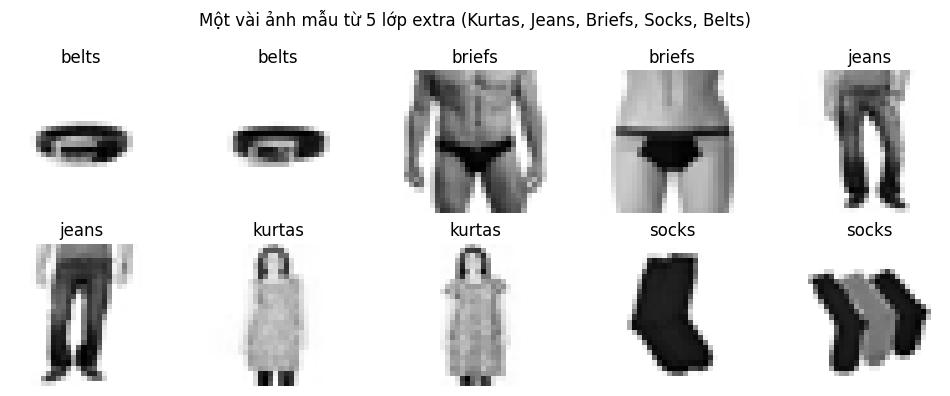

In [11]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [10]. [Đếm ảnh mỗi lớp & hiển thị ảnh mẫu]

for cls_name in sorted(os.listdir(output_root)):
    cls_path = os.path.join(output_root, cls_name)
    num_files = len(os.listdir(cls_path))
    print(f"Lớp '{cls_name}': {num_files} ảnh")

# Hiển thị 2 ảnh mẫu mỗi lớp (nếu có)
plt.figure(figsize=(10, 4))
i = 1
for cls_name in sorted(os.listdir(output_root)):
    cls_path = os.path.join(output_root, cls_name)
    sample_files = os.listdir(cls_path)[:2]
    for fname in sample_files:
        img_path = os.path.join(cls_path, fname)
        img = Image.open(img_path)
        plt.subplot(2, 5, i)
        plt.imshow(img, cmap='gray')
        plt.title(cls_name)
        plt.axis('off')
        i += 1

plt.suptitle("Một vài ảnh mẫu từ 5 lớp extra (Kurtas, Jeans, Briefs, Socks, Belts)")
plt.tight_layout()
plt.show()


## 5. Load & chuẩn hoá Fashion-MNIST (10 lớp)

Trong bước này:

- Load Fashion-MNIST từ `tf.keras.datasets.fashion_mnist`.
- Chuẩn hoá về `[0,1]`.
- Thêm channel để ảnh có shape `(N, 28, 28, 1)`.
- Lưu tên 10 lớp gốc để vẽ biểu đồ & confusion matrix sau này.


In [12]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [12]. [Load & chuẩn hoá Fashion-MNIST]

(x_train_fm, y_train_fm), (x_test_fm, y_test_fm) = fashion_mnist.load_data()

x_train_fm = x_train_fm.astype("float32") / 255.0
x_test_fm  = x_test_fm.astype("float32") / 255.0

x_train_fm = np.expand_dims(x_train_fm, axis=-1)
x_test_fm  = np.expand_dims(x_test_fm, axis=-1)

print("Fashion-MNIST train:", x_train_fm.shape, y_train_fm.shape)
print("Fashion-MNIST test :", x_test_fm.shape,  y_test_fm.shape)

fashion_class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


Fashion-MNIST train: (60000, 28, 28, 1) (60000,)
Fashion-MNIST test : (10000, 28, 28, 1) (10000,)


## 6. Load 5 lớp extra từ thư mục `data_extra_5/`

Dùng `ImageDataGenerator.flow_from_directory()` để:

- Tự động đọc ảnh theo cấu trúc thư mục con.
- Rescale pixel về `[0,1]`.
- Xây dựng mảng:

  - `x_extra`: ảnh (N_extra, 28, 28, 1)
  - `y_extra`: nhãn (N_extra,) với giá trị 0–4.


In [13]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [14]. [Load 5 lớp extra bằng ImageDataGenerator]

extra_datagen = ImageDataGenerator(rescale=1./255.)

extra_generator = extra_datagen.flow_from_directory(
    output_root,
    target_size=(28, 28),
    color_mode='grayscale',
    batch_size=256,
    class_mode='sparse',
    shuffle=True,
    seed=SEED
)

x_extra_list = []
y_extra_list = []

for i in range(len(extra_generator)):
    x_batch, y_batch = extra_generator[i]
    x_extra_list.append(x_batch)
    y_extra_list.append(y_batch)
    if (i + 1) * extra_generator.batch_size >= extra_generator.samples:
        break

x_extra = np.vstack(x_extra_list)
y_extra = np.concatenate(y_extra_list).astype(int)

print("Extra data shape:", x_extra.shape, y_extra.shape)
print("class_indices extra:", extra_generator.class_indices)


Found 3956 images belonging to 5 classes.
Extra data shape: (3956, 28, 28, 1) (3956,)
class_indices extra: {'belts': 0, 'briefs': 1, 'jeans': 2, 'kurtas': 3, 'socks': 4}


## 7. Gộp Fashion-MNIST (10 lớp) + extra (5 lớp) → dataset 15 lớp

Các bước:

1. Gộp toàn bộ Fashion-MNIST:
   - `X_fashion_all = concat(x_train_fm, x_test_fm)`
   - `y_fashion_all = concat(y_train_fm, y_test_fm)`
2. Dịch nhãn extra từ 0–4 lên **10–14**:
   - `y_extra_shift = y_extra + 10`.
3. Ghép hai nguồn:
   - `X_all = concat(X_fashion_all, x_extra)`
   - `y_all = concat(y_fashion_all, y_extra_shift)`
4. Tạo danh sách tên lớp `all_class_names` gồm 15 lớp.
5. Thống kê phân bố số mẫu từng lớp & vẽ biểu đồ.


X_all: (73956, 28, 28, 1)
y_all: (73956,)
Số lớp: 15
Danh sách tên lớp (15): ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot', 'belts', 'briefs', 'jeans', 'kurtas', 'socks']

Phân bố nhãn:
   0 (T-shirt/top): 7000
   1 (Trouser): 7000
   2 (Pullover): 7000
   3 (Dress): 7000
   4 (Coat): 7000
   5 (Sandal): 7000
   6 (Shirt): 7000
   7 (Sneaker): 7000
   8 (Bag): 7000
   9 (Ankle boot): 7000
  10 (belts): 813
  11 (briefs): 849
  12 (jeans): 608
  13 (kurtas): 1000
  14 (socks): 686


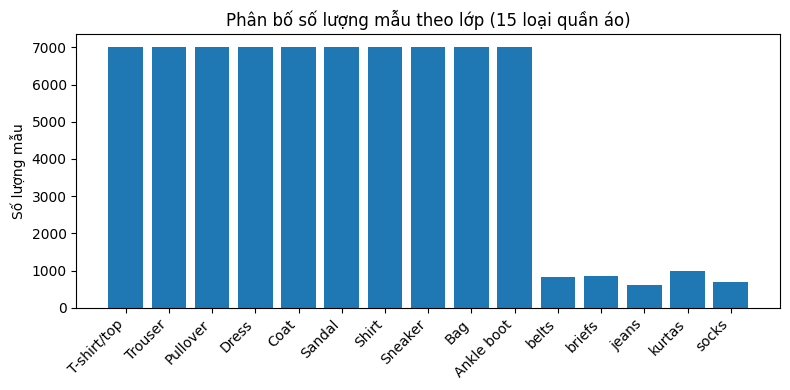

In [14]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [16]. [Gộp 15 lớp & mô tả phân bố]

# Gộp Fashion-MNIST
X_fashion_all = np.concatenate([x_train_fm, x_test_fm], axis=0)
y_fashion_all = np.concatenate([y_train_fm, y_test_fm], axis=0)

# Dịch nhãn extra
y_extra_shift = y_extra + 10  # 0–4 -> 10–14

# Gộp hai nguồn
X_all = np.concatenate([X_fashion_all, x_extra], axis=0)
y_all = np.concatenate([y_fashion_all, y_extra_shift], axis=0)

num_classes = len(np.unique(y_all))
print("X_all:", X_all.shape)
print("y_all:", y_all.shape)
print("Số lớp:", num_classes)

# Tên lớp extra theo thứ tự class_indices 0..4
extra_class_map = {v: k for k, v in extra_generator.class_indices.items()}
extra_class_names = [extra_class_map[i] for i in range(len(extra_class_map))]

all_class_names = fashion_class_names + extra_class_names
print("Danh sách tên lớp (15):", all_class_names)

# Thống kê phân bố
unique, counts = np.unique(y_all, return_counts=True)
print("\nPhân bố nhãn:")
for u, c in zip(unique, counts):
    print(f"  {u:2d} ({all_class_names[u]}): {c}")

plt.figure(figsize=(8, 4))
plt.bar([all_class_names[i] for i in unique], counts)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Số lượng mẫu")
plt.title("Phân bố số lượng mẫu theo lớp (15 loại quần áo)")
plt.tight_layout()
plt.show()


## 8. Chia dữ liệu thành Train / Validation / Test

Sử dụng `train_test_split`:

- Bước 1: chia `X_all`, `y_all` thành:
  - Train: 70%
  - Temp (Val+Test): 30%
- Bước 2: chia tiếp Temp thành:
  - Validation: 15% tổng (nửa của temp).
  - Test: 15% tổng.

Dùng tham số `stratify` để giữ phân bố lớp tương đối đều trong cả 3 tập.


In [15]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [18]. [Chia train / validation / test]

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all,
    test_size=0.30,
    random_state=SEED,
    stratify=y_all
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape,   y_val.shape)
print("Test :", X_test.shape,  y_test.shape)


Train: (51769, 28, 28, 1) (51769,)
Val  : (11093, 28, 28, 1) (11093,)
Test : (11094, 28, 28, 1) (11094,)


## 9. Bổ sung Dropout & Regularization để giảm overfitting

Sau khi thử nghiệm mô hình CNN cơ bản, ta nhận thấy xu hướng **overfitting**:
- Training accuracy tăng cao nhanh.
- Validation accuracy tăng chậm hoặc dừng sớm.
- Val loss có dấu hiệu tăng sau vài epoch.

Để khắc phục, ta bổ sung 2 kỹ thuật regularization phổ biến:

### 1. Dropout

Dropout sẽ:
- **Ngẫu nhiên tắt** một tỷ lệ neuron trong quá trình huấn luyện.
- Ngăn mô hình **phụ thuộc quá mức** vào một số đặc trưng riêng lẻ.
- Giúp cải thiện khả năng tổng quát hóa (generalization).

Các lớp sử dụng Dropout:
- Sau **MaxPooling** block 1 → Dropout(0.2)
- Sau **MaxPooling** block 2 → Dropout(0.2)
- Sau **Dense(128)** → Dropout(0.2)

---

### 2. Regularization (L2 – Weight decay)

Sử dụng `kernel_regularizer=tf.keras.regularizers.l2(1e-4)` cho:

- Tất cả các **Conv2D layers**
- Các **Dense layers**

Tác dụng:

\[
Loss = CrossEntropy + \lambda ||W||^2
\]

- Trừng phạt các trọng số quá lớn.
- Giúp mô hình **ổn định hơn**, tránh overfitting.

---

### 3. Kiến trúc cuối cùng

CNN gồm:

**Conv2D ×4 + Dense ×3 = 7 learnable layers**

Kèm theo:
- 2 lớp `MaxPooling`
- 3 lớp `Dropout`

→ Tổng thể đáp ứng yêu cầu đề bài.


In [18]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [20]. [Xây dựng mô hình CNN với Softmax + Dropout + L2 Regularization]

from tensorflow.keras import regularizers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


l2_reg = regularizers.l2(1e-4)

input_shape = (28, 28, 1)

model = Sequential([

    # ==== Block 1 ====
    Conv2D(
        32, (3, 3), 
        activation='relu', 
        padding='same',
        kernel_regularizer=l2_reg,
        input_shape=input_shape
    ),
    
    Conv2D(
        32, (3, 3),
        activation='relu',
        padding='same',
        kernel_regularizer=l2_reg
    ),
    
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # ==== Block 2 ====
    Conv2D(
        64, (3, 3),
        activation='relu',
        padding='same',
        kernel_regularizer=l2_reg
    ),
    
    Conv2D(
        64, (3, 3),
        activation='relu',
        padding='same',
        kernel_regularizer=l2_reg
    ),
    
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # ==== Fully Connected ====
    Flatten(),
    
    Dense(
        256,
        activation='relu',
        kernel_regularizer=l2_reg
    ),
    
    Dense(
        128,
        activation='relu',
        kernel_regularizer=l2_reg
    ),

    Dropout(0.2),

    # ==== Output ====
    Dense(
        num_classes,
        activation='softmax'
    )
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 14, 14, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 14, 14, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 7, 7, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 3136)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │         803,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 15)                  │           1,935 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 902,895 (3.44 MB)

 Trainable params: 902,895 (3.44 MB)

 Non-trainable params: 0 (0.00 B)

## 10. Compile & huấn luyện mô hình

Cài đặt huấn luyện:

- Loss: `sparse_categorical_crossentropy`
- Optimizer: `Adam`
- Metric: `accuracy`

Callbacks:

- `EarlyStopping`: dừng sớm nếu `val_loss` không cải thiện sau vài epoch.
- `ModelCheckpoint`: lưu lại model có `val_loss` thấp nhất.


In [19]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [22]. [Compile & train mô hình CNN]

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

EPOCHS = 20
BATCH_SIZE = 128

callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint("best_fashion_15classes.h5", monitor='val_loss', save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
404/405 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.6866 - loss: 0.9745

405/405 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - accuracy: 0.7997 - loss: 0.6329 - val_accuracy: 0.8852 - val_loss: 0.3853
Epoch 2/20
404/405 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8826 - loss: 0.3892

405/405 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.8873 - loss: 0.3754 - val_accuracy: 0.9059 - val_loss: 0.3218
Epoch 3/20
404/405 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9021 - loss: 0.3333

405/405 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.9045 - loss: 0.3276 - val_accuracy: 0.9128 - val_loss: 0.3008
Epoch 4/20
404/405 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9155 - loss: 0.2993

405/405 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.9150 - loss: 0.2996 - val_accuracy: 0.9177 - val_loss: 0.2970
Epoch 5/20
404/405 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9226 - loss: 0.2809

405/405 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.9220 - loss: 0.2814 - val_accuracy: 0.9214 - val_loss: 0.2858
Epoch 6/20
404/405 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9303 - loss: 0.2630

405/405 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.9293 - loss: 0.2664 - val_accuracy: 0.9246 - val_loss: 0.2792
Epoch 7/20
404/405 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9343 - loss: 0.2571

405/405 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.9332 - loss: 0.2591 - val_accuracy: 0.9273 - val_loss: 0.2756
Epoch 8/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.9387 - loss: 0.2487 - val_accuracy: 0.9261 - val_loss: 0.2807
Epoch 9/20
404/405 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9445 - loss: 0.2366

405/405 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.9436 - loss: 0.2385 - val_accuracy: 0.9290 - val_loss: 0.2754
Epoch 10/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 23s 56ms/step - accuracy: 0.9460 - loss: 0.2374 - val_accuracy: 0.9319 - val_loss: 0.2786
Epoch 11/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.9490 - loss: 0.2316 - val_accuracy: 0.9296 - val_loss: 0.2882
Epoch 12/20
405/405 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.9511 - loss: 0.2246 - val_accuracy: 0.9291 - val_loss: 0.2915


## 11. Trực quan hoá quá trình huấn luyện

Sử dụng `history.history` để vẽ:

- Training loss vs Validation loss.
- Training accuracy vs Validation accuracy.

Mục đích:

- Phân tích overfitting / underfitting.
- Minh họa quá trình hội tụ của mô hình trong báo cáo.


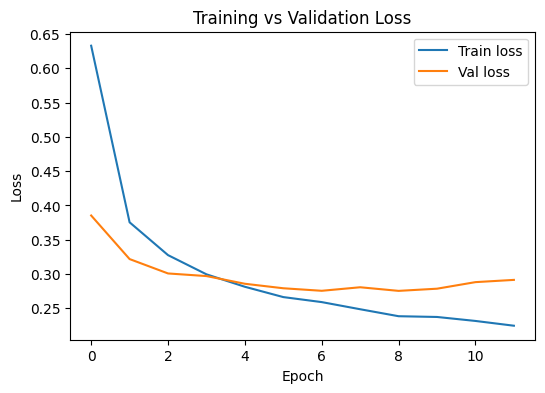

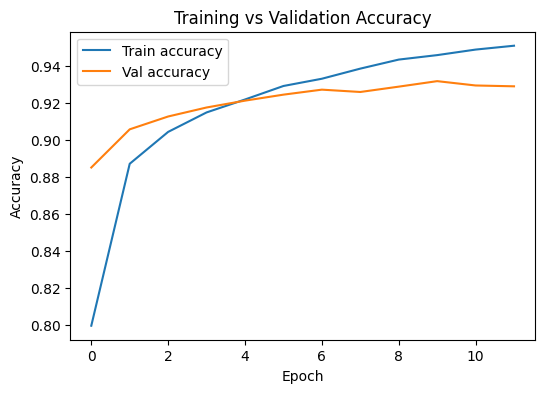

In [20]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [24]. [Vẽ đồ thị loss/val_loss và accuracy/val_accuracy]

# Loss
plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

# Accuracy
plt.figure(figsize=(6, 4))
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


## 12. Đánh giá mô hình trên Test set & Confusion Matrix

Các bước:

1. Dùng `model.evaluate(X_test, y_test)` để tính:
   - Test loss.
   - Test accuracy.
2. Dùng `model.predict(X_test)` để lấy vector xác suất Softmax cho từng mẫu.
3. `argmax` theo trục lớp để lấy nhãn dự đoán.
4. Tính **confusion matrix** và vẽ heatmap.
5. In **classification report** (precision, recall, F1-score) của từng lớp.


Test Loss     : 0.2878
Test Accuracy : 0.9272
347/347 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


<Figure size 800x600 with 0 Axes>

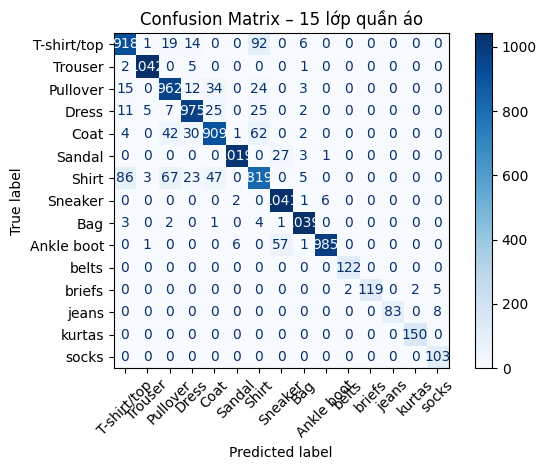

Classification report:
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.87      0.88      1050
     Trouser       0.99      0.99      0.99      1050
    Pullover       0.88      0.92      0.90      1050
       Dress       0.92      0.93      0.92      1050
        Coat       0.89      0.87      0.88      1050
      Sandal       0.99      0.97      0.98      1050
       Shirt       0.80      0.78      0.79      1050
     Sneaker       0.92      0.99      0.96      1050
         Bag       0.98      0.99      0.98      1050
  Ankle boot       0.99      0.94      0.96      1050
       belts       0.98      1.00      0.99       122
      briefs       1.00      0.93      0.96       128
       jeans       1.00      0.91      0.95        91
      kurtas       0.99      1.00      0.99       150
       socks       0.89      1.00      0.94       103

    accuracy                           0.93     11094
   macro avg       0.94      0.94      0.94     11094
wei

In [21]:
#B22DCCN476 - Đỗ Ngọc Lâm
#Cell [26]. [Đánh giá trên test set & vẽ confusion matrix]

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

# Dự đoán xác suất Softmax
y_prob = model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=all_class_names)
plt.figure(figsize=(8, 6))
disp.plot(xticks_rotation=45, cmap='Blues', values_format='d')
plt.title("Confusion Matrix – 15 lớp quần áo")
plt.tight_layout()
plt.show()

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=all_class_names))
